In [2]:
!pip install ultralytics wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:00


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import wandb

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset: COCO128

COCO128 is chosen as it provides diverse object instances and annotations, making it suitable for learning object detection, which forms the foundation of object tracking. Its small size also enables fast experimentation.

In [4]:
WANDB_PROJECT = "yolo11n-coco128-experiments"
WANDB_ENTITY  = None

## Hyperparameter Tuning Approach

In [5]:
experiments = [
    {"lr": 0.01,  "batch": 16, "epochs": 100, "name": "exp1_baseline"},
    {"lr": 0.1,   "batch": 16, "epochs": 100, "name": "exp2_high_lr"},
    {"lr": 0.001, "batch": 16, "epochs": 100, "name": "exp3_low_lr"},
    {"lr": 0.01,  "batch": 8,  "epochs": 100, "name": "exp4_small_batch"},
    {"lr": 0.01,  "batch": 16, "epochs": 200, "name": "exp5_more_epochs"},
]

results_summary = []

The experiments are conducted to evaluate the impact of different hyperparameters on model performance. By varying one parameter at a time while keeping others constant, a fair comparison is ensured, helping identify the optimal configuration and understand its effect on training behavior.

## Training and Evaluation of Multiple Hyperparameter Configurations

This section performs systematic experimentation by iterating over predefined hyperparameter settings, training the model independently for each configuration, and logging evaluation metrics to enable performance comparison

In [11]:
for exp in experiments:
    print(f"\n{'='*50}")
    print(f"  Running {exp['name']}  ({experiments.index(exp)+1}/5)")
    print(f"  LR={exp['lr']} | Batch={exp['batch']} | Epochs={exp['epochs']}")
    print(f"{'='*50}")

    wandb.init(
        project="yolo11n-coco128",
        name=exp["name"],
        config=exp,
        reinit=True
    )

    model = YOLO("yolo11n.pt")  # fresh weights each time

    model.train(
        data="coco128.yaml",
        epochs=exp["epochs"],
        imgsz=640,
        batch=exp["batch"],
        lr0=exp["lr"],
        optimizer="SGD",
        name=exp["name"],
        project="runs/detect",
        exist_ok=True,
        verbose=False,
    )

    metrics = model.val(verbose=False)

    results_summary.append({
        "Experiment":  exp["name"],
        "LR":          exp["lr"],
        "Batch":       exp["batch"],
        "Epochs":      exp["epochs"],
        "mAP50":       round(metrics.box.map50, 4),
        "mAP50-95":    round(metrics.box.map,   4),
        "Precision":   round(metrics.box.mp,    4),
        "Recall":      round(metrics.box.mr,    4),
    })

    print(f"Done {exp['name']} — mAP50={metrics.box.map50:.4f}")
    wandb.finish()


  Running exp1_baseline  (1/5)
  LR=0.01 | Batch=16 | Epochs=100


Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plot


  Running exp2_high_lr  (2/5)
  LR=0.1 | Batch=16 | Epochs=100


Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.1, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_high_lr, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots=


  Running exp3_low_lr  (3/5)
  LR=0.001 | Batch=16 | Epochs=100


Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp3_low_lr, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, plots


  Running exp4_small_batch  (4/5)
  LR=0.01 | Batch=8 | Epochs=100


Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp4_small_batch, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, pl


  Running exp5_more_epochs  (5/5)
  LR=0.01 | Batch=16 | Epochs=200


Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp5_more_epochs, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100, perspective=0.0, p

In [19]:
df = pd.DataFrame(results_summary)

df.to_csv("results_table.csv", index=False)

print("\nFinal Results Table:")
print(df.to_string(index=False))


Final Results Table:
      Experiment    LR  Batch  Epochs  mAP50  mAP50-95  Precision  Recall
   exp1_baseline 0.010     16     100 0.9203    0.7894     0.9303  0.8374
    exp2_high_lr 0.100     16     100 0.6387    0.4712     0.7148  0.5660
     exp3_low_lr 0.001     16     100 0.8851    0.7345     0.8472  0.8293
exp4_small_batch 0.010      8     100 0.9110    0.7749     0.9201  0.8379
exp5_more_epochs 0.010     16     200 0.9431    0.8427     0.9366  0.8860


exp1_baseline (LR = 0.01, Batch = 16, Epochs = 100)
Provides strong and stable performance, serving as a reference for comparison.

exp2_high_lr (LR = 0.1, Batch = 16, Epochs = 100)
Performance drops significantly due to unstable training caused by a high learning rate.

exp3_low_lr (LR = 0.001, Batch = 16, Epochs = 100)
More stable training but slightly lower performance due to slower learning.

exp4_small_batch (LR = 0.01, Batch = 8, Epochs = 100)
Performance is similar to baseline; smaller batch size has minimal impact.

exp5_more_epochs (LR = 0.01, Batch = 16, Epochs = 200)
Achieves the best performance as longer training improves convergence.


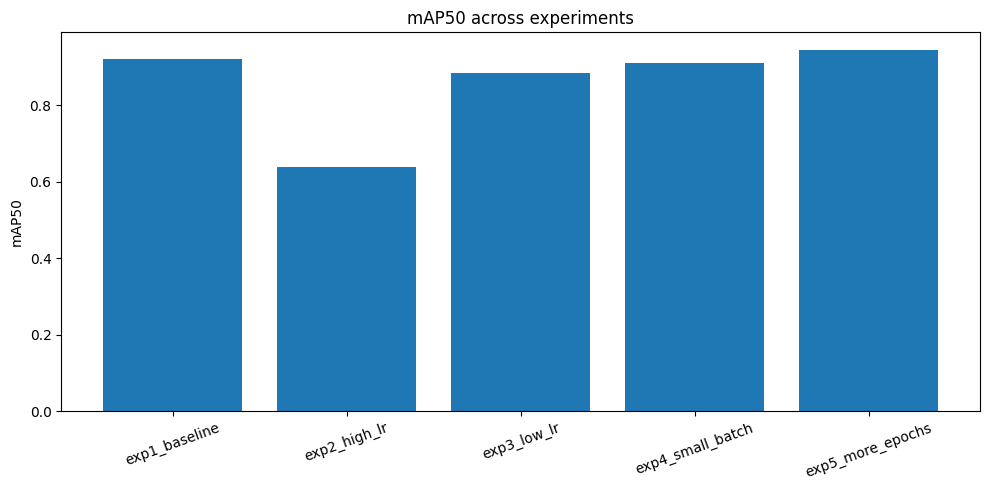

In [20]:
plt.figure(figsize=(10,5))
plt.bar(df["Experiment"], df["mAP50"])
plt.xticks(rotation=20)
plt.ylabel("mAP50")
plt.title("mAP50 across experiments")
plt.tight_layout()
plt.savefig("map_graph.png")
plt.show()

The bar chart shows the variation of mAP50 across different hyperparameter configurations.
The baseline model achieves strong performance, indicating that the default parameters are effective. Increasing the learning rate results in a significant drop in mAP50, highlighting unstable training at higher learning rates. Reducing the learning rate improves stability but does not surpass the baseline.
Changing the batch size has minimal impact on performance, as seen from similar mAP values. The highest mAP50 is achieved when the number of epochs is increased, indicating that longer training leads to better convergence and improved accuracy.

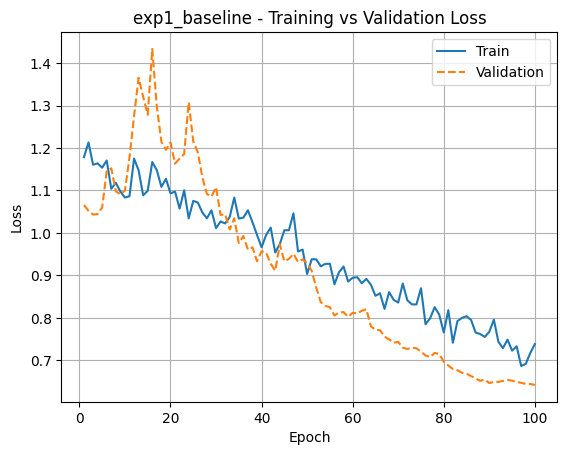

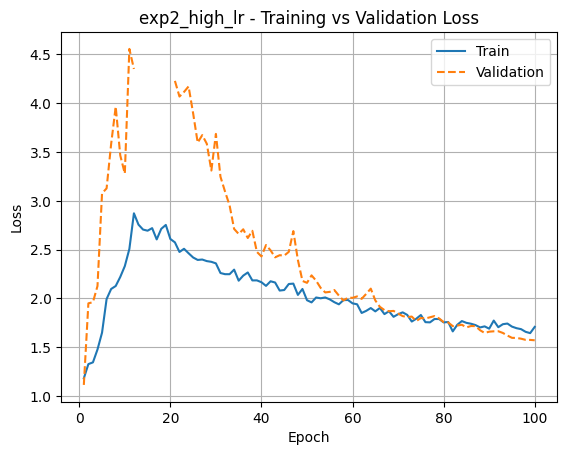

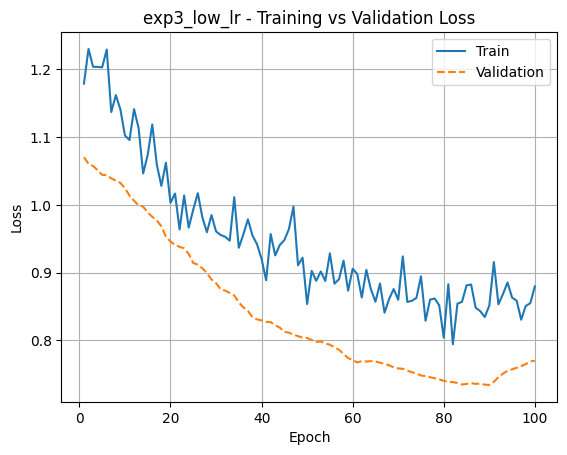

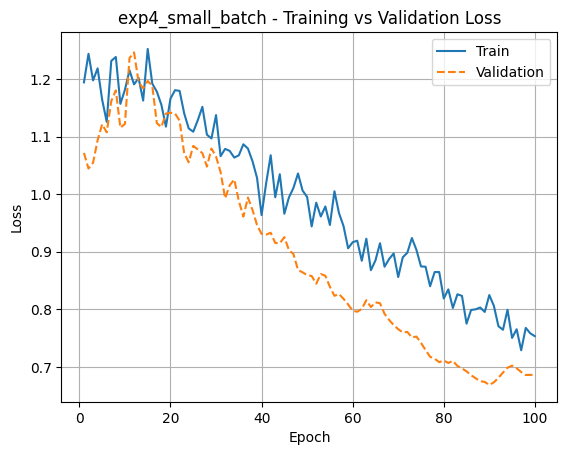

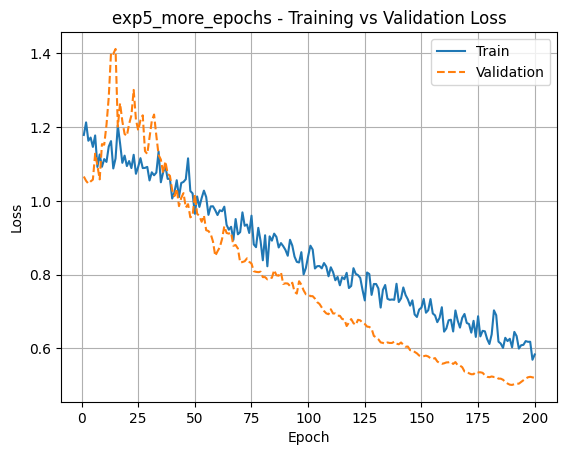

In [24]:
base_path = "/content/runs/detect/runs/detect"

for exp in experiments:
    path = os.path.join(base_path, exp["name"], "results.csv")

    if os.path.exists(path):
        log = pd.read_csv(path)
        log.columns = log.columns.str.strip()

        plt.figure()

        plt.plot(log["epoch"], log["train/box_loss"], label="Train")
        plt.plot(log["epoch"], log["val/box_loss"], linestyle='--', label="Validation")

        plt.title(f"{exp['name']} - Training vs Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid()

        plt.savefig(f"{exp['name']}_loss.png")
        plt.show()

exp1_baseline
Both training and validation loss decrease steadily, indicating stable learning and good convergence.

exp2_high_lr
Loss values are very high and fluctuate significantly, showing unstable training due to an excessively high learning rate.

exp3_low_lr
Loss decreases smoothly but slowly, indicating stable yet slower convergence.

exp4_small_batch
Loss trends are similar to baseline, with slightly more fluctuations due to smaller batch size, but overall stable learning.

exp5_more_epochs
Loss continues to decrease over more epochs, achieving the lowest values, indicating better convergence and improved performance.

In [2]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

Among all the experiments, exp5_more_epochs achieved the best performance in terms of mAP, precision, and recall. The improved results indicate better convergence due to increased training epochs.

Therefore, this model is selected as the final model and will be used for subsequent tasks such as object tracking.

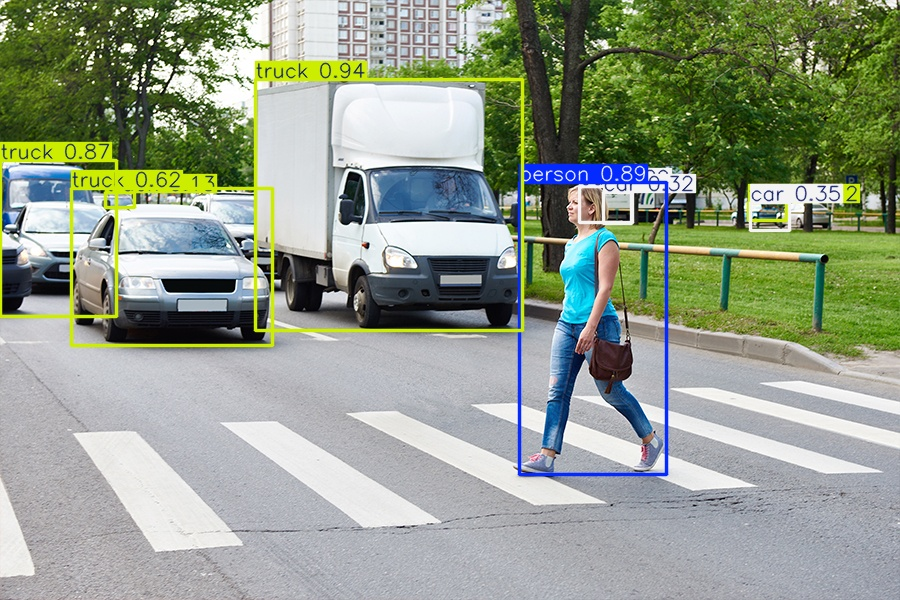

In [4]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict/pedestrian.jpg"))